Directory 'output' already exists.
Directory 'plots' already exists.


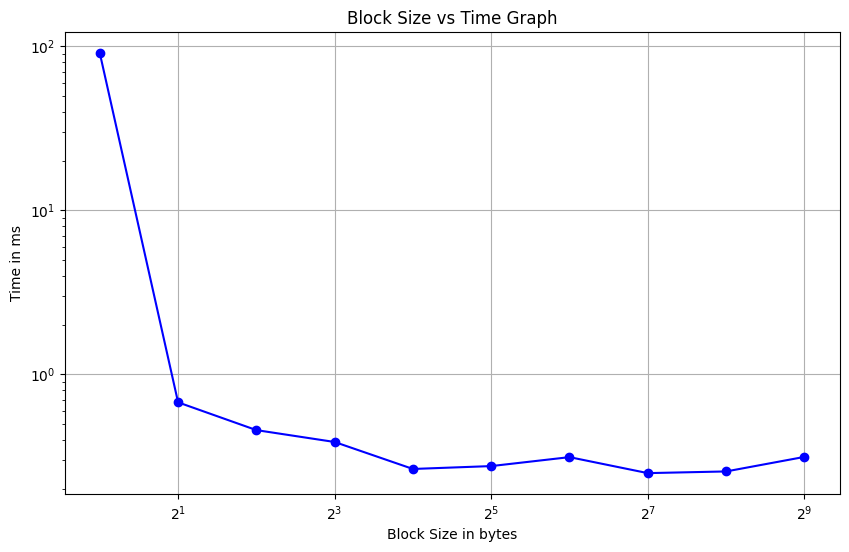

In [10]:
# HPC Labwork 3 : Hello, CUDA!
# by Lucien Elyas Bedrane - 2640012

#!pip install numba

import numba
import matplotlib.pyplot as plt
import numpy as np
import time
import os

from numba import cuda

def grayscale_CPU(src, dst):
 for i in range(0, len(src), 3):
  dst[i] = dst[i+1] = dst[i+2] = (src[i] + src[i+1] + src[i+2]) / 3

@cuda.jit
def grayscale_GPU(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] * 255 + src[tidx,1] * 255 + src[tidx,2] * 255) / 3)
  dst[tidx,0] = dst[tidx,1] = dst[tidx,2] = g

#We create the folders for the different outputs that we will generate.
for directory_name in ["output", "plots"] :
  try:
      os.mkdir(directory_name)
      print(f"Directory '{directory_name}' created successfully.")
  except FileExistsError:
      print(f"Directory '{directory_name}' already exists.")
  except PermissionError:
      print(f"Permission denied: Unable to create '{directory_name}'.")
  except Exception as e:
      print(f"An error occurred: {e}")

#We load here the source image and flatten it to a 1D-array
img = plt.imread('src/cat.png')
image_src = np.reshape(img, (-1, 3))
pixelCount = image_src.shape[0]

#We initialize the blockSize and gridSize that will be used to test the GPU version of grayscale
blockSize = [int(2**x) for x in range(11)] #blockSize of 2^11 or higher makes the program crash
gridSize = [int(pixelCount / x) for x in blockSize]

#We copy here into the GPU memory the source image for the GPU version of greyscale
devSrc = cuda.to_device(image_src)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

time_records = []

#In this loop, we try the GPU version of grayscale with different size of blocks and grids
for i in range(len(blockSize)):
    start_time = time.time()
    grayscale_GPU[gridSize[i], blockSize[i]](devSrc, devDst)
    hostDst = devDst.copy_to_host()
    end_time = time.time()

    time_records.append(end_time - start_time)

    output_image = np.reshape(hostDst, img.shape)
    plt.imsave("output/gpu_output_" + str(i) + ".png", output_image)

#We use the CPU version of grayscale
image_src_flat = image_src.flatten()
output_cpu = np.zeros(len(image_src_flat))
grayscale_CPU(image_src_flat, output_cpu)
cpu_image = np.reshape(output_cpu, img.shape)
plt.imsave("output/cpu_output.png", cpu_image)

#We convert the recorded time in seconds to ms required for each loop of the GPU version of grayscale
time_records_in_ms = [t * 1000 for t in time_records]

#We plot and save the graph of Block Size vs Time
plt.figure(figsize=(10, 6))
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.plot(blockSize, time_records_in_ms, linestyle="-", color="blue", marker="o")
plt.title("Block Size vs Time Graph")
plt.xlabel("Block Size in bytes")
plt.ylabel("Time in ms")
plt.grid(True)
plt.savefig("plots/BlockSize_vs_Time_Graph.png")
